<a href="https://colab.research.google.com/github/johnpaulzaralspu/ZARA-CSST_101-BSCS_3B/blob/main/CSST102_Exercise2_Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Pipeline using the UCI Wine Dataset**

## **1. Import Libraries**

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import machine learning modules from scikit-learn
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

## **2. Load and Understand the dataset**

In [ ]:
# Convert the Wine CSV file to a DataFrame
df = pd.read_csv('UCI_Wine_Dataset_178.csv')

In [ ]:
# View Top 5 rows
df.head()

,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# View dataset shape
print('Rows and columns:', df.shape)

Rows and columns: (178, 14)


In [ ]:
# View Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malicacid                     178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity_of_ash             178 non-null    float64
 5   Magnesium                     178 non-null    float64
 6   Total_phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid_phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color_intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280_OD315_of_diluted_wines  178 non-null    float64
 13  Proli

In [ ]:
# View descriptive statistics
df.describe()

,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
# View value counts of the target Class column
df['class'].value_counts().sort_index()

,count
class,
1,59
2,71
3,48


In [ ]:
# Check for missing values
df.isnull().sum()

,0
class,0
Alcohol,0
Malicacid,0
Ash,0
Alcalinity_of_ash,0
Magnesium,0
Total_phenols,0
Flavanoids,0
Nonflavanoid_phenols,0
Proanthocyanins,0


## **3. Visualize the dataset**

### **Histogram**

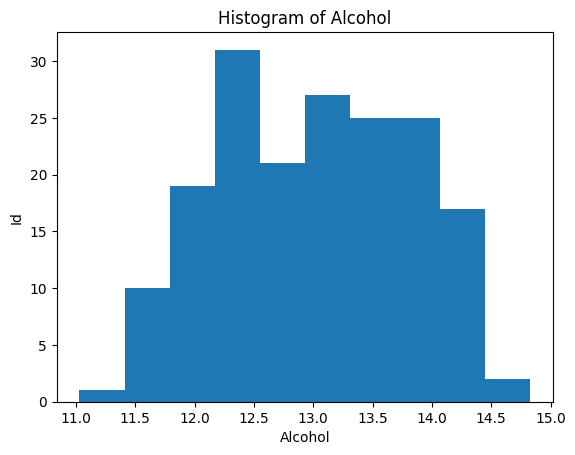

In [ ]:
# Plot a histogram to show the distribution of Alcohol
plt.hist(df['Alcohol'])
plt.xlabel('Alcohol')
plt.ylabel('Id')
plt.title('Histogram of Alcohol')
plt.show()

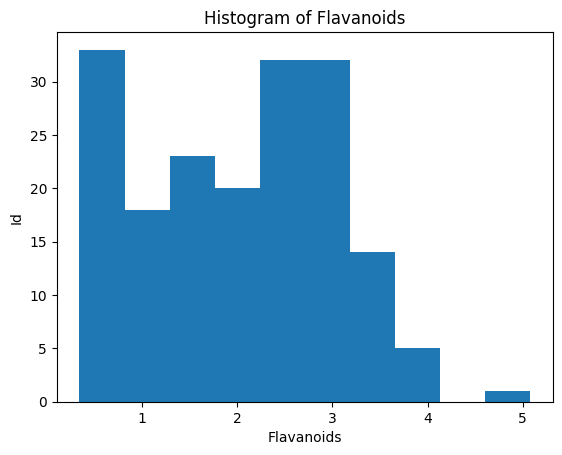

In [ ]:
# Plot a histogram to show the distribution of Proline
plt.hist(df['Flavanoids'])
plt.xlabel('Flavanoids')
plt.ylabel('Id')
plt.title('Histogram of Flavanoids')
plt.show()

### **Scatter Plot**

In [ ]:
# Assign a color for each wine class
color = {1: 'red',
         2: 'blue',
         3: 'green'}

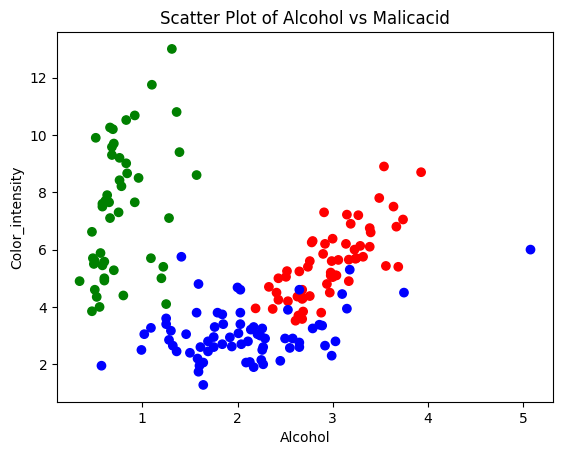

In [ ]:
plt.scatter(df['Flavanoids'], df['Color_intensity'], c=df['class'].map(color))
plt.xlabel('Alcohol')
plt.ylabel('Color_intensity')
plt.title('Scatter Plot of Alcohol vs Malicacid')
plt.show()

## **4. Feature Selection**

In [ ]:
X = df.drop("class", axis = 1)
y = df["class"]

F, p = f_classif(X, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": F,
    "p_value": p
})

feature_scores = feature_scores.sort_values(
    "F_Score",
    ascending=False
)

feature_scores

,Feature,F_Score,p_value
6,Flavanoids,233.925873,3.598586e-50
12,Proline,207.920374,5.783168e-47
11,OD280_OD315_of_diluted_wines,189.972321,1.393105e-44
0,Alcohol,135.077624,3.319504e-36
9,Color_intensity,120.664018,1.162008e-33
10,Hue,101.316795,5.917662e-30
5,Total_phenols,93.733010,2.137670e-28
1,Malicacid,36.943425,4.127229e-14
3,Alcalinity_of_ash,35.771637,9.444473e-14
8,Proanthocyanins,30.271383,5.125359e-12


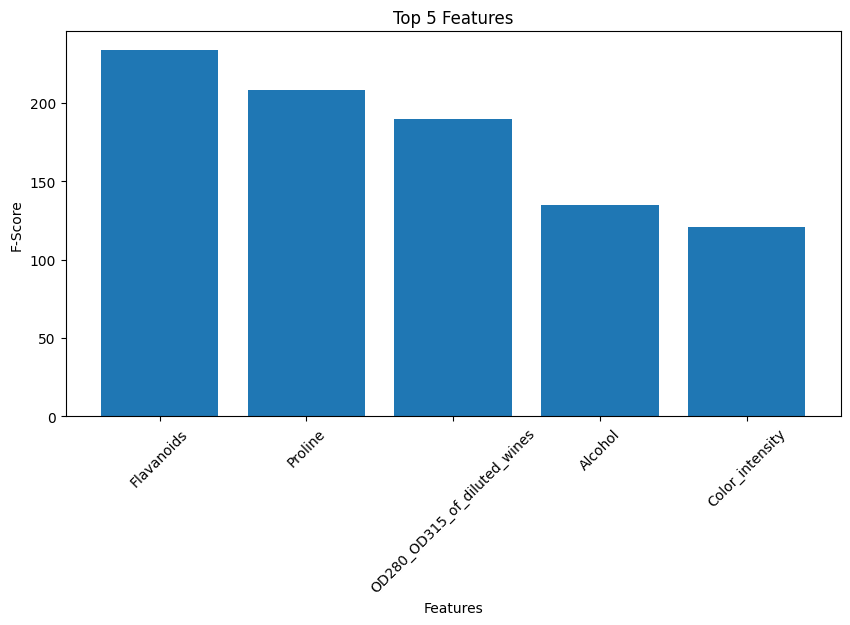

In [ ]:
top_features = feature_scores.head(5)

plt.figure(figsize=(10, 5))
plt.bar(top_features["Feature"], top_features["F_Score"])

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("F-Score")
plt.title("Top 5 Features")
plt.show()

## **5. Split the dataset into training set and testing set**

In [ ]:
# Features: all columns except the target class
X = df.drop(columns='class').values

# Labels: wine class
y = df['class'].values

In [ ]:
# Split the dataset: 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(142, 13)
(36, 13)
(142,)
(36,)


In [ ]:
# View the training features
print(X_train)

[[1.434e+01 1.680e+00 2.700e+00 ... 5.700e-01 1.960e+00 6.600e+02]
 [1.253e+01 5.510e+00 2.640e+00 ... 8.200e-01 1.690e+00 5.150e+02]
 [1.237e+01 1.070e+00 2.100e+00 ... 1.040e+00 2.770e+00 6.600e+02]
 ...
 [1.438e+01 1.870e+00 2.380e+00 ... 1.200e+00 3.000e+00 1.547e+03]
 [1.269e+01 1.530e+00 2.260e+00 ... 9.600e-01 2.060e+00 4.950e+02]
 [1.234e+01 2.450e+00 2.460e+00 ... 8.000e-01 3.380e+00 4.380e+02]]


In [ ]:
# View the training labels
print(y_train)

[3 3 2 3 1 2 2 2 3 1 2 2 3 1 2 1 1 3 3 2 2 1 2 1 3 2 2 3 1 1 1 3 1 1 2 3 2
 1 3 2 1 3 2 2 1 2 1 1 2 1 1 3 2 2 2 1 2 2 2 3 3 1 2 3 3 2 2 1 2 3 3 2 3 2
 2 2 1 1 3 1 3 1 1 2 2 1 1 1 2 1 2 3 2 2 2 3 3 2 1 1 2 3 3 1 2 3 3 3 3 2 1
 2 1 3 1 1 2 1 1 3 2 1 3 3 1 1 3 3 3 2 2 2 2 2 2 3 1 2 2 1 2 2]


## **6. Create the Model**

**Choose Machine Learning Algorithm**

In [ ]:
# Create a K-Nearest Neighbors classifier
knn = KNeighborsClassifier(n_neighbors=21)

**Train the Model**

In [ ]:
# Train the model using the training data
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=21)

**Test the Model**

In [ ]:
# Predict the classes of the test data
y_pred = knn.predict(X_test)

# Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

# Precision
precision = metrics.precision_score(y_test, y_pred, average='weighted')
print('\nPrecision:', precision)

# Recall
recall = metrics.recall_score(y_test, y_pred, average='weighted')
print('\nRecall:', recall)

# F1-Score
f1 = metrics.f1_score(y_test, y_pred, average='weighted')
print('\nF1-Score:', f1)

Accuracy: 0.7777777777777778

Precision: 0.7922558922558923

Recall: 0.7777777777777778

F1-Score: 0.7789357173265219


In [ ]:
# Display the confusion matrix
metrics.confusion_matrix(y_test, y_pred)

array([[14,  0,  0],
       [ 0,  9,  5],
       [ 3,  2,  3]])

## **7. Test the Model (Prediction)**

In [ ]:
prediction = knn.predict([[14.23, 1.71, 2.43, 15.6, 127.0, 2.80, 3.06, 0.28, 2.29, 5.64, 1.04, 3.92, 1065.0]])

print('Predicted Wine Class:', prediction[0])

Predicted Wine Class: 1
